# Chapter 08: Large-scale Geometry

**Source Span.** *A Course in Metric Geometry*, Chapter 8, printed pages 271-306, PDF pages 286-321. The PDF was used for orientation only: section order, terminology, theorem targets, and examples. All prose, examples, code, diagrams, and checks here are original.

**Chapter question.** What remains visible when the measuring instrument has bounded additive error, or even bounded multiplicative error? This chapter replaces local exactness by coarse tests: pointed noncompact limits, tangent and asymptotic cones, quasi-isometries, Gromov hyperbolicity, and periodic metrics with stable norms.


## Visual Storyboard and Library Routing

| Source | Representation | What to inspect | Artifact |
| --- | --- | --- | --- |
| 8.1 pointed limits | balls in larger cycle graphs | fixed-radius balls stabilize while whole spaces do not | `pointed-cycle-balls-limit.png` |
| 8.2 cones | scaled lattice clouds | mesh size and covering radius shrink under rescaling | `cone-rescaling-snapshots.png`, `cone-rescaling-lab.html` |
| 8.3 quasi-isometries | lattice net and growth curves | bounded distortion versus polynomial/exponential growth | `quasi-isometry-net-growth.png` |
| 8.4 hyperbolicity | four-point and thin-triangle residuals | tree residuals vanish; grids keep square detours | `hyperbolicity-diagnostics.png` |
| 8.5 periodic metrics | weighted periodic Cayley metric | scaled balls approach a stable norm polygon | `periodic-stable-norm-ball.png` |

NetworkX handles finite graph metrics and Cayley-style models, Matplotlib records durable static figures, Plotly provides the cone slider as standalone HTML, SciPy solves tiny linear programs for stable norms, and Pandas writes the asymptotic growth table.


## Translation Guide

Large-scale geometry changes the unit of attention. A compact-space question asks whether the whole metric space is close to another whole metric space. A pointed noncompact question asks something weaker and more useful: after choosing basepoints, do all bounded-radius neighborhoods eventually look the same? This is why the first model uses graph balls instead of entire graphs.

A rescaling limit has two directions. Sending the scale factor to infinity magnifies a point and asks for a tangent cone. Sending the scale factor to zero compresses far-away geometry and asks for an asymptotic cone. The lattice experiment is intentionally simple because it exposes the invariant that matters: the mesh bound tends to zero, so bounded windows become indistinguishable from the limiting normed plane.

A quasi-isometry is not a near-isometry. It can ignore bounded local damage and tolerate controlled stretch. That is why nets, orbits of cocompact group actions, and Cayley graphs can replace smoother spaces in coarse arguments. What survives is not an exact angle or curvature value, but growth type, hyperbolicity, and the shape of asymptotic norm balls.

Gromov hyperbolicity is treated here as a diagnostic rather than a slogan. Thin triangles give the picture; the four-point inequality gives a distance-only test that works even when geodesics are not convenient to draw. Periodic metrics close the chapter by showing how repeated local rules average into a stable norm at infinity.


In [1]:
from pathlib import Path
import itertools, json, math

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import networkx as nx
import plotly.graph_objects as go
from scipy.optimize import linprog
from scipy.spatial import ConvexHull
from IPython.display import HTML, Image, Markdown, display

BOOK_ROOT = Path.cwd()
for c in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (c / "AGENTS.md").exists() and (c / "source_map.json").exists():
        BOOK_ROOT = c
        break
if not (BOOK_ROOT / "AGENTS.md").exists():
    course = BOOK_ROOT / "A-Course-in-Metric-Geometry"
    if (course / "AGENTS.md").exists() and (course / "source_map.json").exists():
        BOOK_ROOT = course

ART = BOOK_ROOT / "artifacts" / "chapter-08"
FIG = ART / "figures"; HTML_DIR = ART / "html"; CHECK = ART / "checks"; TABLE = ART / "tables"
for p in [FIG, HTML_DIR, CHECK, TABLE]:
    p.mkdir(parents=True, exist_ok=True)

def rel(p):
    return str(Path(p).relative_to(BOOK_ROOT)).replace("\\", "/")

def write_json(p, payload):
    p = Path(p); p.parent.mkdir(parents=True, exist_ok=True)
    p.write_text(json.dumps(payload, indent=2, sort_keys=True), encoding="utf-8")
    return p

def display_artifact(p, width=760, height=520):
    p = Path(p)
    if p.suffix.lower() == ".png":
        display(Image(filename=str(p), width=width))
    elif p.suffix.lower() == ".html":
        display(HTML(f'<iframe src="{p.as_posix()}" width="{width}" height="{height}" style="border:1px solid #ddd"></iframe>'))
    else:
        display(Markdown(f"[`{rel(p)}`]({rel(p)})"))

sections = [
    {"section": "8.1", "title": "Noncompact Gromov-Hausdorff Limits", "printed_start": 271, "pdf_start": 286},
    {"section": "8.2", "title": "Tangent and Asymptotic Cones", "printed_start": 275, "pdf_start": 290},
    {"section": "8.3", "title": "Quasi-isometries", "printed_start": 277, "pdf_start": 292},
    {"section": "8.4", "title": "Gromov Hyperbolic Spaces", "printed_start": 284, "pdf_start": 299},
    {"section": "8.5", "title": "Periodic Metrics", "printed_start": 298, "pdf_start": 313},
]
write_json(CHECK / "visual-storyboard.json", {
    "chapter_goal": "Teach large-scale metric invariants through finite graph, cone, hyperbolicity, and stable-norm experiments.",
    "source_span": {"printed": "271-306", "pdf": "286-321", "used_for": "orientation only"},
    "visual_sequence": ["pointed balls", "cone rescaling lab", "quasi-isometry growth", "hyperbolicity residuals", "periodic stable norm"],
    "libraries": ["networkx", "matplotlib", "plotly", "scipy", "pandas"],
})
write_json(CHECK / "source-coverage.json", {
    "chapter": "08-large-scale-geometry",
    "printed_pages": "271-306",
    "pdf_pages": "286-321",
    "sections": sections,
    "coverage": [
        {"section": "8.1", "artifacts": ["figures/pointed-cycle-balls-limit.png", "checks/noncompact-pointed-limit.json"]},
        {"section": "8.2", "artifacts": ["figures/cone-rescaling-snapshots.png", "html/cone-rescaling-lab.html", "checks/cone-rescaling-checks.json"]},
        {"section": "8.3", "artifacts": ["figures/quasi-isometry-net-growth.png", "checks/quasi-isometry-checks.json"]},
        {"section": "8.4", "artifacts": ["figures/hyperbolicity-diagnostics.png", "checks/hyperbolicity-residuals.json"]},
        {"section": "8.5", "artifacts": ["figures/periodic-stable-norm-ball.png", "tables/periodic-growth.csv", "checks/periodic-stable-norm-checks.json"]},
    ],
    "copyright_note": "No textbook prose, figures, screenshots, or page crops are used.",
})
print("artifact root:", ART)


artifact root: D:\Geometry\A-Course-in-Metric-Geometry\artifacts\chapter-08


## 8.1 Pointed Balls Replace Whole Noncompact Spaces

For noncompact spaces, the chapter asks for convergence around chosen basepoints and fixed radii. The cycle graphs `C_N` give a finite laboratory: the whole graph is always a loop, but the ball of radius `r` around vertex `0` has the same distance matrix as the integer interval `[-r,r]` once the cycle is large enough. The check below compares distance matrices, not just drawings.


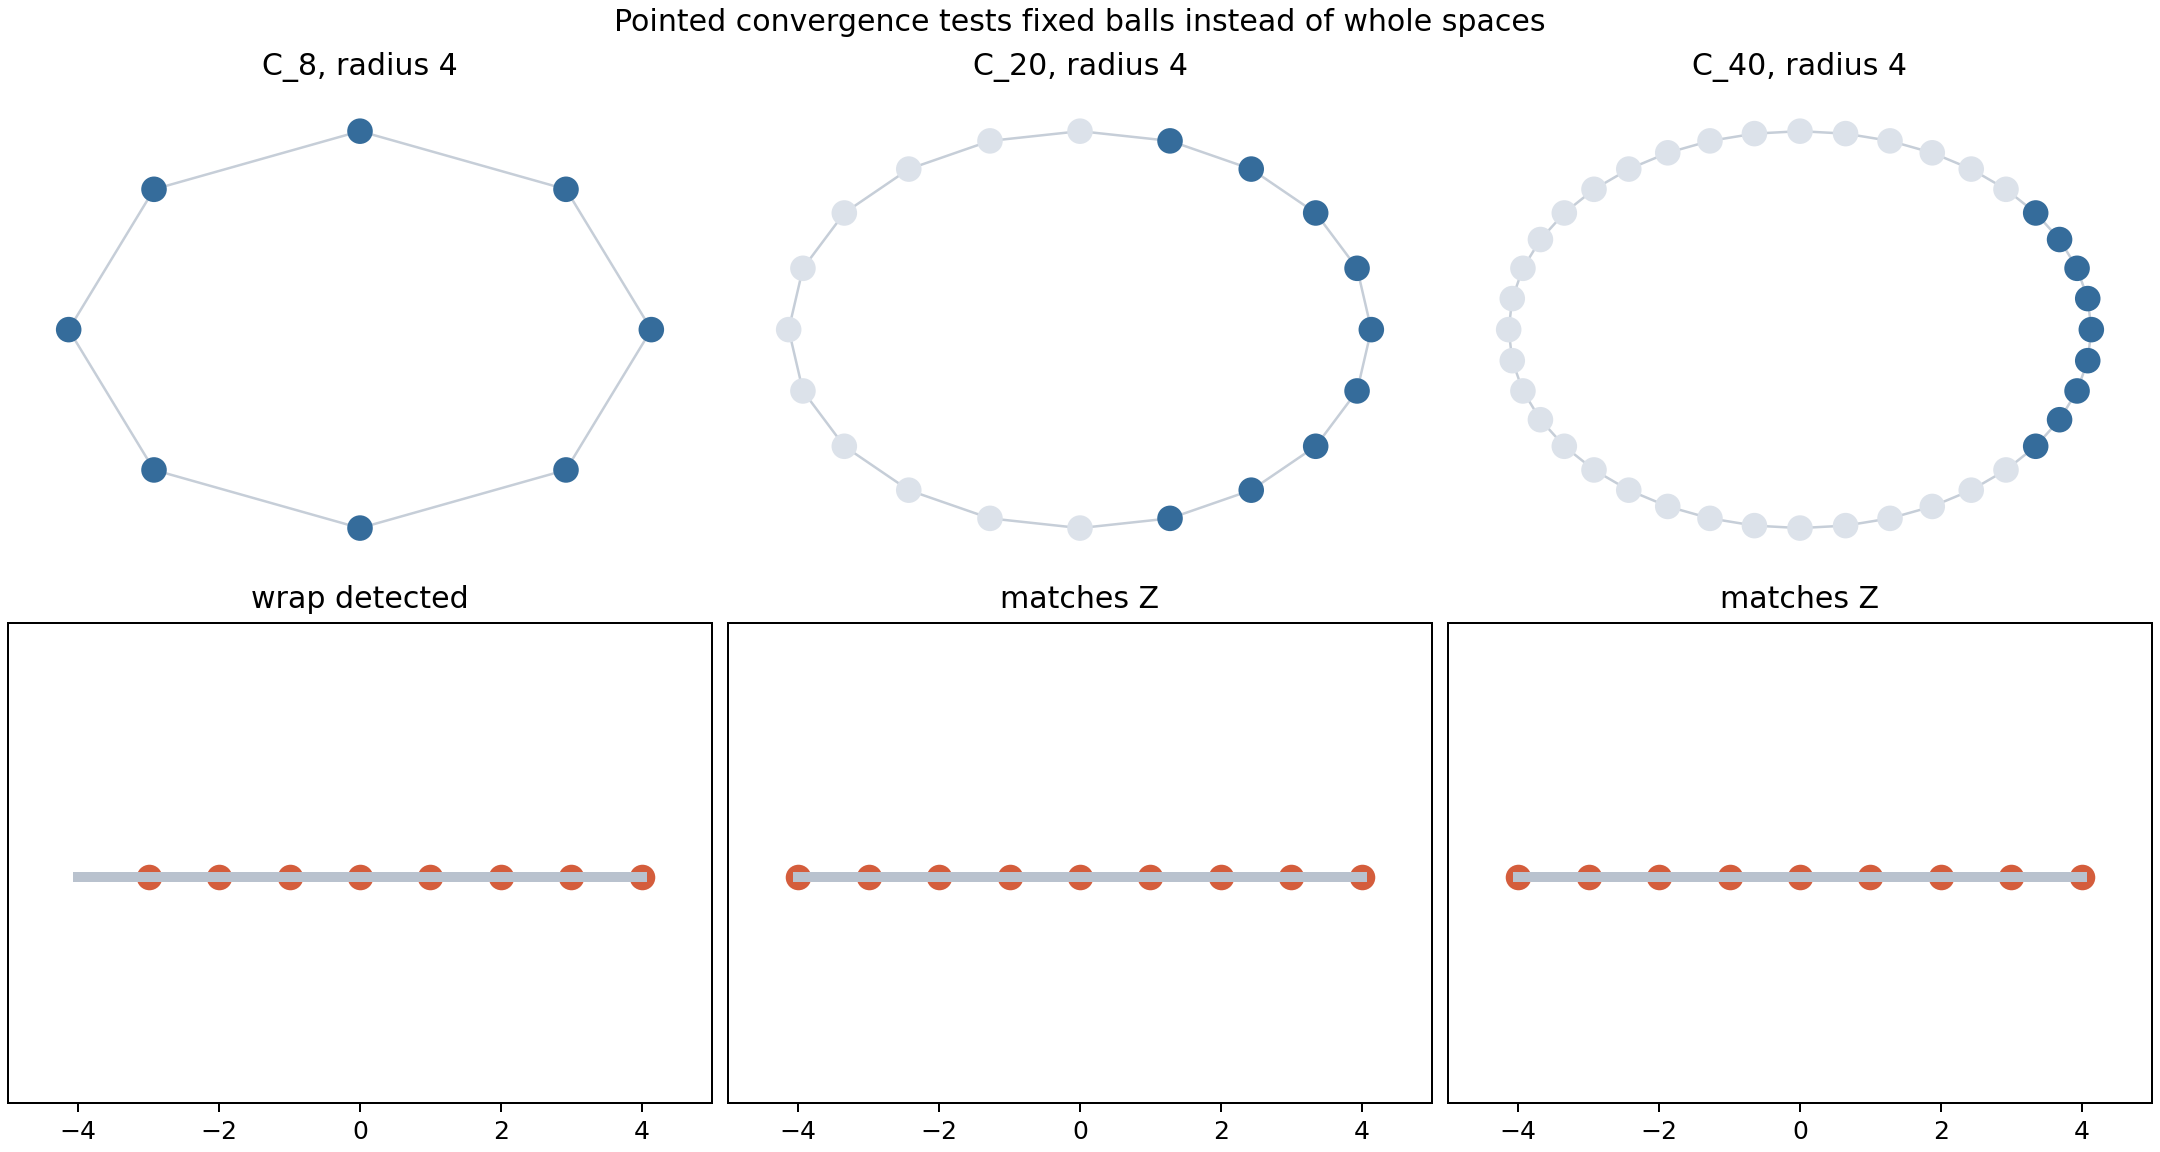

{'model': 'pointed cycles converge locally to the integer line',
 'radius': 4,
 'cases': [{'cycle_vertices': 8,
   'radius': 4,
   'ball_cardinality': 8,
   'matches_integer_interval_distance_matrix': False},
  {'cycle_vertices': 20,
   'radius': 4,
   'ball_cardinality': 9,
   'matches_integer_interval_distance_matrix': True},
  {'cycle_vertices': 40,
   'radius': 4,
   'ball_cardinality': 9,
   'matches_integer_interval_distance_matrix': True}],
 'eventual_local_stability_detected': True}

In [2]:
r = 4
line = list(range(-r, r + 1))
line_dm = np.array([[abs(a - b) for b in line] for a in line])
cases = []
fig, ax = plt.subplots(2, 3, figsize=(12, 6.4), constrained_layout=True)
for col, N in enumerate([8, 20, 40]):
    G = nx.cycle_graph(N)
    ball = sorted(nx.single_source_shortest_path_length(G, 0, cutoff=r))
    unwrap = {k: k if k <= N // 2 else k - N for k in ball}
    ordered = sorted(ball, key=lambda k: unwrap[k])
    dm = np.array([[nx.shortest_path_length(G, a, b) for b in ordered] for a in ordered])
    match = bool(dm.shape == line_dm.shape and np.array_equal(dm, line_dm))
    cases.append({"cycle_vertices": N, "radius": r, "ball_cardinality": len(ball), "matches_integer_interval_distance_matrix": match})
    pos = nx.circular_layout(G)
    nx.draw_networkx_edges(G, pos, ax=ax[0, col], edge_color="#c6ced8")
    nx.draw_networkx_nodes(G, pos, ax=ax[0, col], node_size=85, node_color=["#356c9b" if n in ball else "#dce2ea" for n in G])
    ax[0, col].set_title(f"C_{N}, radius {r}"); ax[0, col].axis("off")
    xs = [unwrap[k] for k in ordered]
    ax[1, col].plot(line, np.zeros(len(line)), color="#b9c2ce", lw=4)
    ax[1, col].scatter(xs, np.zeros(len(xs)), s=85, color="#d45d3c")
    ax[1, col].set_xlim(-r - 1, r + 1); ax[1, col].set_ylim(-.4, .45); ax[1, col].set_yticks([])
    ax[1, col].set_title("matches Z" if match else "wrap detected")
fig.suptitle("Pointed convergence tests fixed balls instead of whole spaces")
pointed_fig = FIG / "pointed-cycle-balls-limit.png"
fig.savefig(pointed_fig, dpi=180); plt.close(fig)
pointed_check = {"model": "pointed cycles converge locally to the integer line", "radius": r, "cases": cases, "eventual_local_stability_detected": all(c["matches_integer_interval_distance_matrix"] for c in cases[1:])}
write_json(CHECK / "noncompact-pointed-limit.json", pointed_check)
display_artifact(pointed_fig); pointed_check


## 8.2 Rescaling Toward Cones

Tangent cones magnify; asymptotic cones shrink. In the lattice model, shrinking distances by `lambda` is the same as plotting `lambda Z^2` in a fixed window. The point count rises, but the meaningful quantity is the mesh size and the covering-radius bound `sqrt(2) lambda / 2`. The HTML artifact gives the same experiment as a slider.


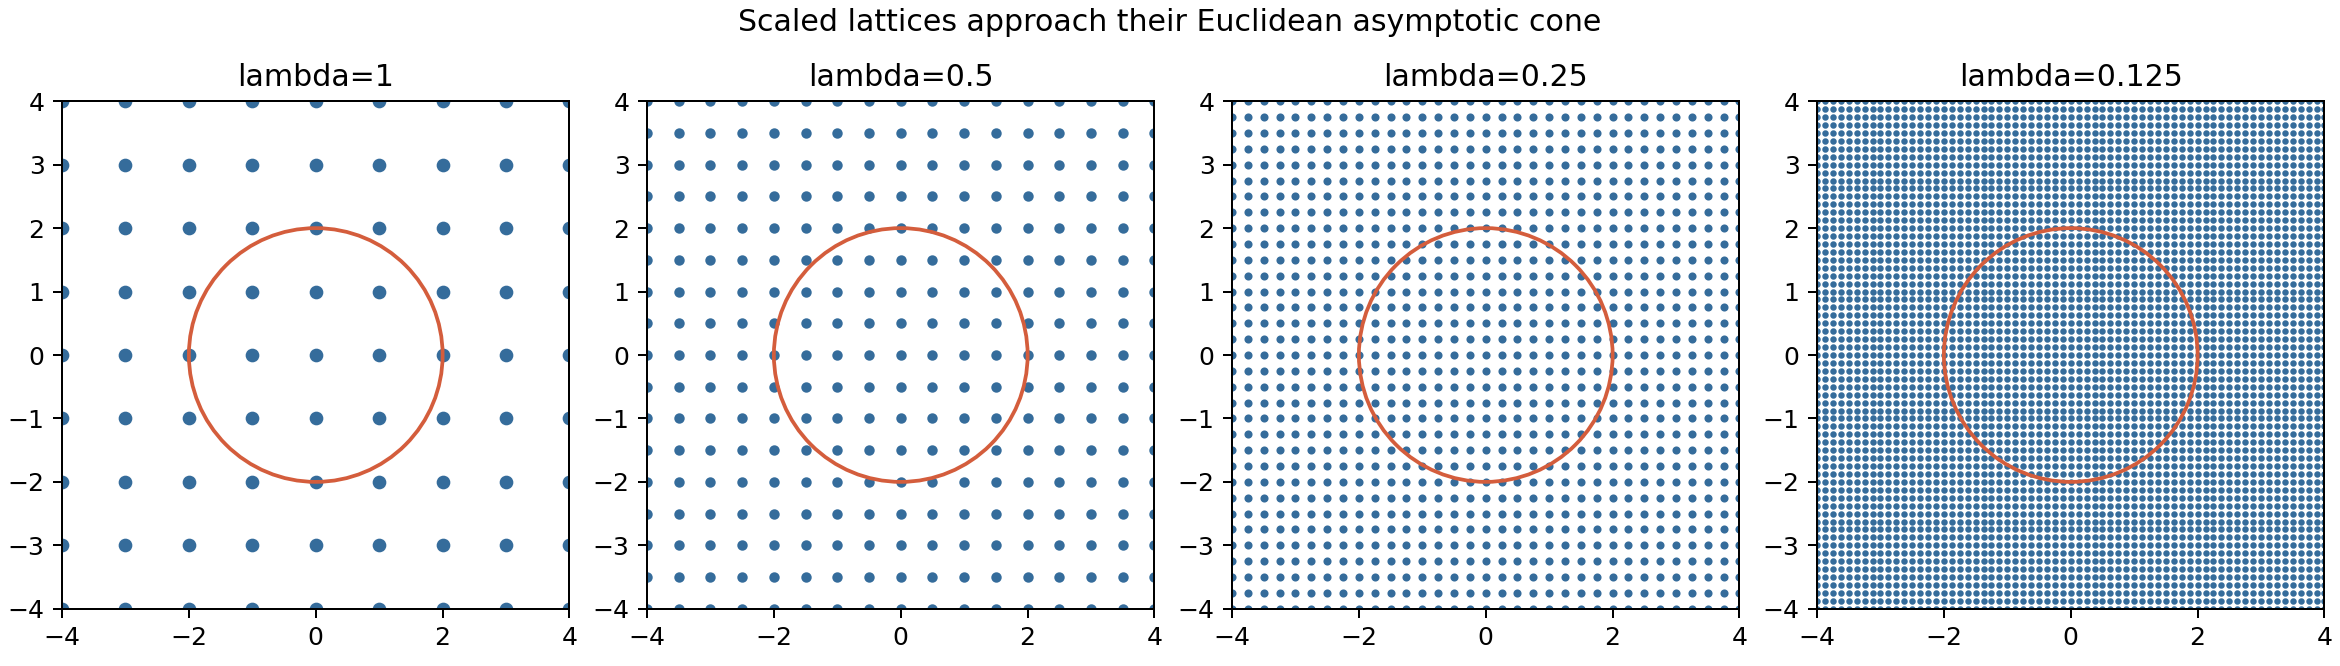

D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


{'model': 'lambda Z^2 in a fixed window',
 'records': [{'scale_lambda': 1.0,
   'mesh_size': 1.0,
   'points_in_window': 81,
   'euclidean_covering_radius_bound': 0.7071067811865476},
  {'scale_lambda': 0.5,
   'mesh_size': 0.5,
   'points_in_window': 289,
   'euclidean_covering_radius_bound': 0.3535533905932738},
  {'scale_lambda': 0.25,
   'mesh_size': 0.25,
   'points_in_window': 1089,
   'euclidean_covering_radius_bound': 0.1767766952966369},
  {'scale_lambda': 0.125,
   'mesh_size': 0.125,
   'points_in_window': 4225,
   'euclidean_covering_radius_bound': 0.08838834764831845}],
 'covering_radius_strictly_decreases': True}

In [3]:
scales = [1.0, 0.5, 0.25, 0.125]
window = 4.0
records = []
fig, ax = plt.subplots(1, 4, figsize=(13, 3.7), constrained_layout=True)
frames = []
for i, lam in enumerate(scales):
    m = math.ceil(window / lam)
    pts = np.array([(a * lam, b * lam) for a in range(-m, m + 1) for b in range(-m, m + 1)])
    pts = pts[(abs(pts[:, 0]) <= window) & (abs(pts[:, 1]) <= window)]
    records.append({"scale_lambda": lam, "mesh_size": lam, "points_in_window": int(len(pts)), "euclidean_covering_radius_bound": float(math.sqrt(2) * lam / 2)})
    ax[i].scatter(pts[:, 0], pts[:, 1], s=max(2, 20 * lam), color="#356c9b")
    ax[i].add_patch(Circle((0, 0), 2, fill=False, color="#d45d3c", lw=1.5))
    ax[i].set_aspect("equal"); ax[i].set_xlim(-window, window); ax[i].set_ylim(-window, window)
    ax[i].set_title(f"lambda={lam:g}")
    frames.append(go.Frame(data=[go.Scatter(x=pts[:,0], y=pts[:,1], mode="markers", marker={"size": max(3, 9 * lam), "color": "#356c9b"})], name=str(lam)))
fig.suptitle("Scaled lattices approach their Euclidean asymptotic cone")
cone_fig = FIG / "cone-rescaling-snapshots.png"
fig.savefig(cone_fig, dpi=180); plt.close(fig)

theta = np.linspace(0, 2*np.pi, 240)
lab = go.Figure(data=[frames[0].data[0]], frames=frames)
lab.add_trace(go.Scatter(x=2*np.cos(theta), y=2*np.sin(theta), mode="lines", line={"color": "#d45d3c"}, name="radius 2 ball"))
lab.update_layout(width=780, height=620, title="Cone rescaling lab", xaxis={"range": [-window, window], "scaleanchor": "y"}, yaxis={"range": [-window, window]},
                  sliders=[{"steps": [{"method": "animate", "label": str(s), "args": [[str(s)], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}}]} for s in scales], "currentvalue": {"prefix": "lambda = "}}])
cone_html = HTML_DIR / "cone-rescaling-lab.html"
lab.write_html(cone_html, include_plotlyjs="cdn", full_html=True)
cone_check = {"model": "lambda Z^2 in a fixed window", "records": records, "covering_radius_strictly_decreases": all(records[i+1]["euclidean_covering_radius_bound"] < records[i]["euclidean_covering_radius_bound"] for i in range(len(records)-1))}
write_json(CHECK / "cone-rescaling-checks.json", cone_check)
display_artifact(cone_fig); display_artifact(cone_html, height=620); cone_check


## 8.3 Quasi-isometries Forget Bounded Error

A quasi-isometry allows a bounded multiplicative distortion and a bounded additive error. Nets turn this into a working rule: a coarsely dense subset can stand in for the whole space. The inclusion `(Z^2, l1 word metric) -> (R^2, Euclidean)` satisfies `(1/sqrt(2)) d_l1 <= d_E <= d_l1`, so sampled lattice pairs should show no distortion violations. Growth curves then show which coarse features survive.


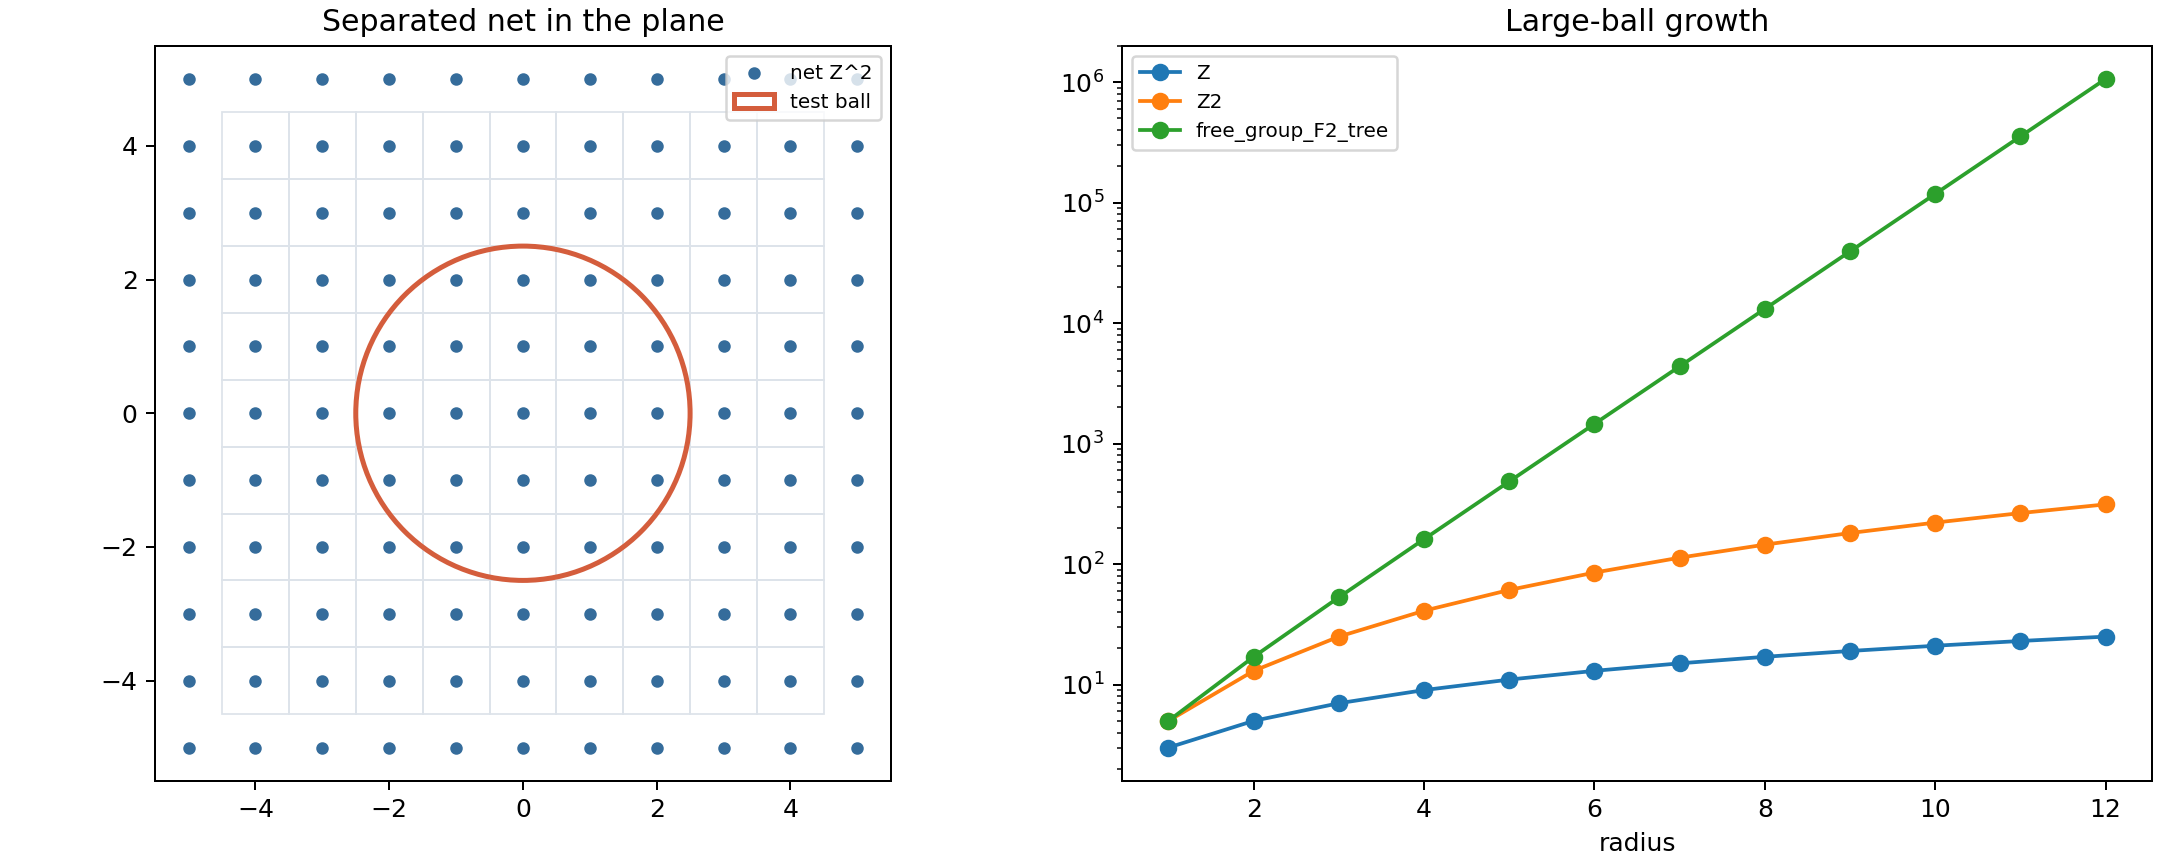

{'sampled_map': 'identity inclusion from (Z^2,l1) to Euclidean R^2',
 'lambda': 1.4142135623730951,
 'additive_C': 0,
 'sampled_pairs': 196,
 'violations': [],
 'minimum_lower_margin': 0.0,
 'minimum_upper_margin': 0.41421356237309515,
 'growth_table_last_radius': {'radius': 12,
  'Z': 25,
  'Z2': 313,
  'free_group_F2_tree': 1062881}}

In [4]:
pts = np.array([(i, j) for i in range(-5, 6) for j in range(-5, 6)], float)
lam = math.sqrt(2); violations = []; lower = []; upper = []
for i in range(0, len(pts), 7):
    for j in range(3, len(pts), 11):
        if i == j: continue
        d1 = float(np.abs(pts[i] - pts[j]).sum()); de = float(np.linalg.norm(pts[i] - pts[j]))
        lower.append(de - d1 / lam); upper.append(lam * d1 - de)
        if not (d1 / lam - 1e-12 <= de <= lam * d1 + 1e-12):
            violations.append({"x": pts[i].tolist(), "y": pts[j].tolist(), "d_l1": d1, "d_euclidean": de})
R = np.arange(1, 13)
growth = pd.DataFrame({"radius": R, "Z": 2*R+1, "Z2": 2*R*R+2*R+1, "free_group_F2_tree": 1 + 4*(3**R - 1)//2})
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
for x in range(-4, 5):
    for y in range(-4, 5):
        ax[0].add_patch(plt.Rectangle((x-.5, y-.5), 1, 1, fill=False, edgecolor="#dde3ea", lw=.7))
ax[0].scatter(pts[:,0], pts[:,1], s=16, color="#356c9b", label="net Z^2")
ax[0].add_patch(Circle((0, 0), 2.5, fill=False, color="#d45d3c", lw=2, label="test ball"))
ax[0].set_aspect("equal"); ax[0].set_title("Separated net in the plane"); ax[0].legend(fontsize=8)
for col in ["Z", "Z2", "free_group_F2_tree"]:
    ax[1].plot(growth["radius"], growth[col], "o-", label=col)
ax[1].set_yscale("log"); ax[1].set_title("Large-ball growth"); ax[1].set_xlabel("radius"); ax[1].legend(fontsize=8)
qi_fig = FIG / "quasi-isometry-net-growth.png"
fig.savefig(qi_fig, dpi=180); plt.close(fig)
qi_check = {"sampled_map": "identity inclusion from (Z^2,l1) to Euclidean R^2", "lambda": lam, "additive_C": 0, "sampled_pairs": len(lower), "violations": violations, "minimum_lower_margin": float(min(lower)), "minimum_upper_margin": float(min(upper)), "growth_table_last_radius": growth.iloc[-1].to_dict()}
write_json(CHECK / "quasi-isometry-checks.json", qi_check)
display_artifact(qi_fig); qi_check


## 8.4 Hyperbolicity from Distance Data

The thin-triangle definition is geometric; the four-point definition uses only distances. On finite graphs we can compute both. For points `a,b,c,p`, the four-point residual is the amount by which `(b,c)_p >= min((a,b)_p,(a,c)_p) - delta` would fail with `delta = 0`. A tree has zero residual. A grid has visible square detours, so its residual is larger.


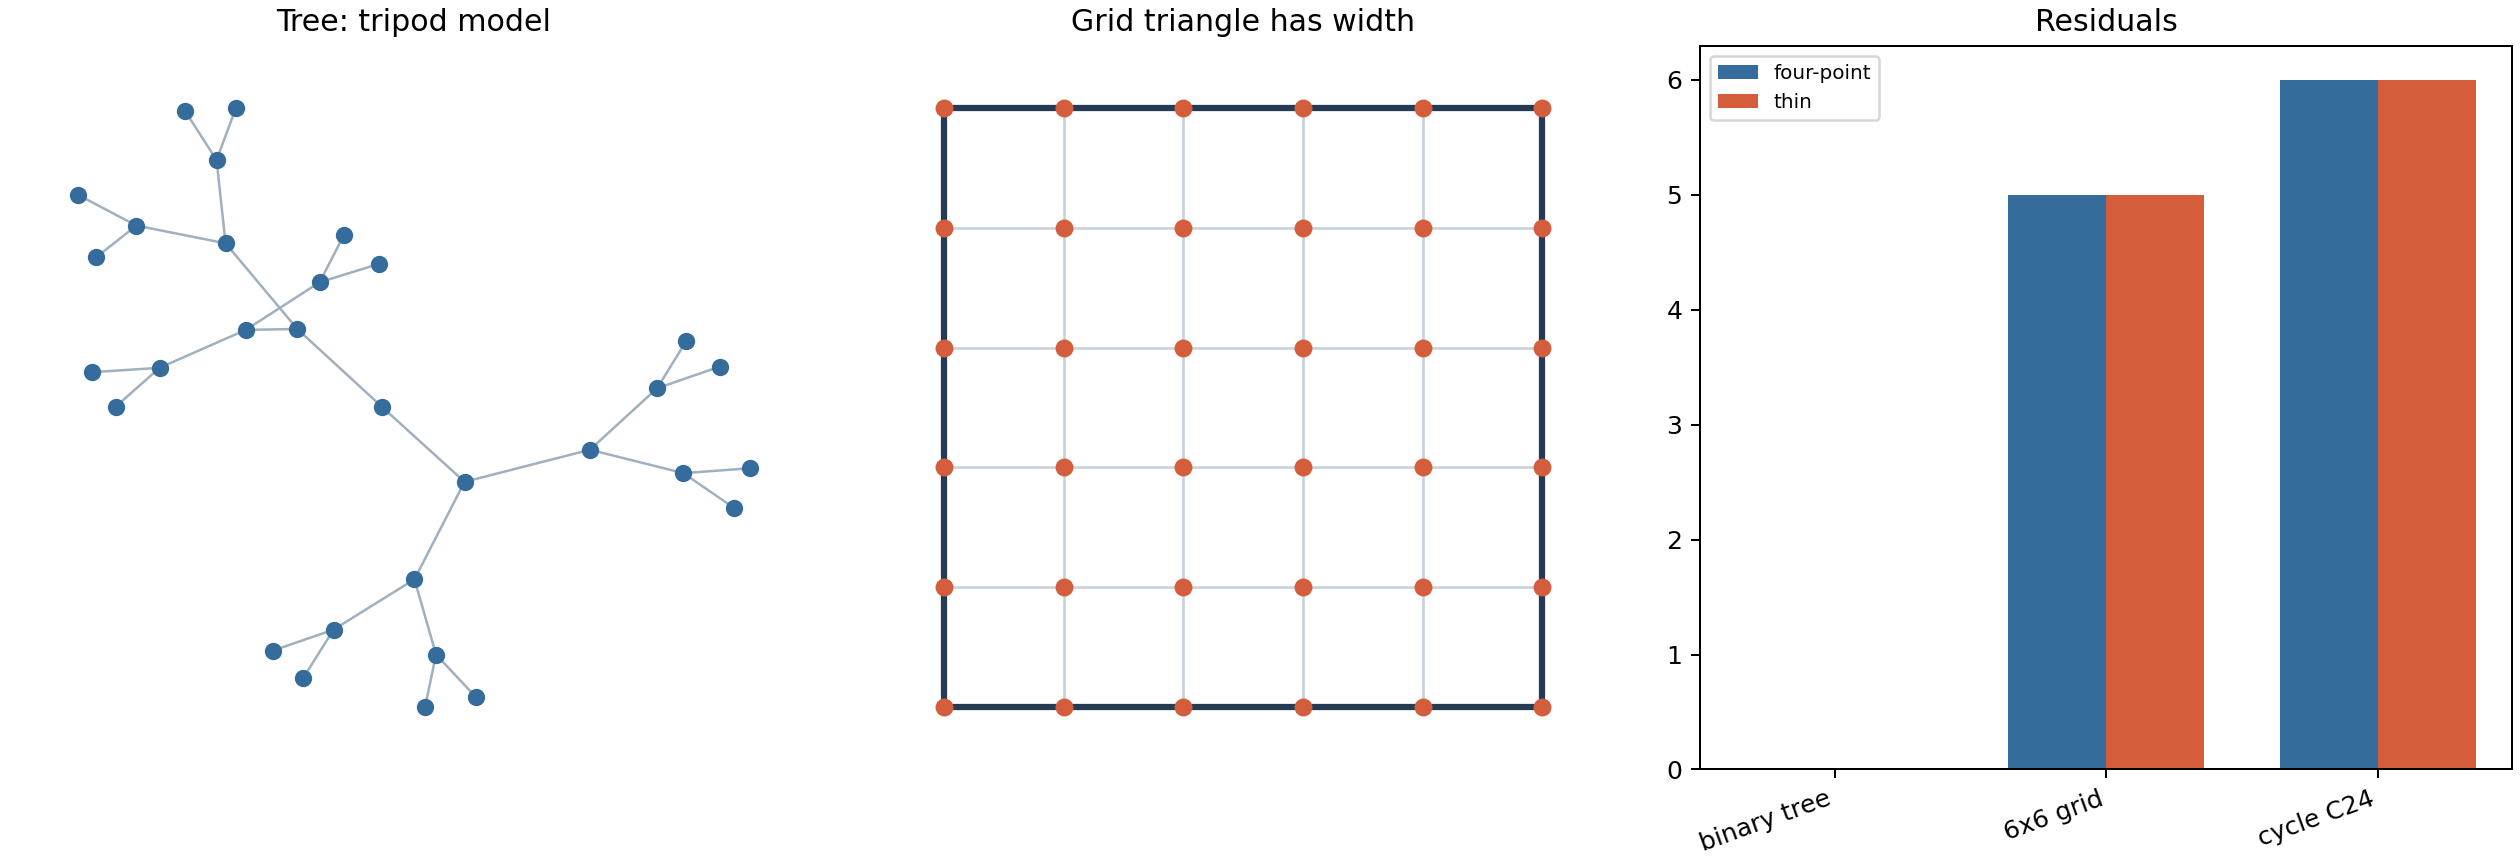

{'definition_tested': 'four-point Gromov-product residual and graph thin-triangle residual',
 'models': [{'space': 'binary tree',
   'vertices': 31,
   'four_point_delta': 0.0,
   'four_point_witness': None,
   'thin_triangle_residual': 0,
   'thin_triangle_witness': None},
  {'space': '6x6 grid',
   'vertices': 36,
   'four_point_delta': 5.0,
   'four_point_witness': {'a': '(0, 0)',
    'b': '(0, 5)',
    'c': '(5, 0)',
    'p': '(5, 5)',
    'residual': 5.0},
   'thin_triangle_residual': 5,
   'thin_triangle_witness': {'a': '(0, 0)',
    'b': '(3, 0)',
    'c': '(5, 5)',
    'side_index': 1,
    'thin_residual': 5}},
  {'space': 'cycle C24',
   'vertices': 24,
   'four_point_delta': 6.0,
   'four_point_witness': {'a': '0',
    'b': '6',
    'c': '18',
    'p': '12',
    'residual': 6.0},
   'thin_triangle_residual': 6,
   'thin_triangle_witness': {'a': '0',
    'b': '12',
    'c': '13',
    'side_index': 0,
    'thin_residual': 6}}],
 'tree_zero_four_point_delta': True,
 'grid_has_la

In [5]:
def gp(dist, p, q, r):
    return 0.5 * (dist[r][p] + dist[r][q] - dist[p][q])

def four_delta(G, nodes):
    dist = dict(nx.all_pairs_shortest_path_length(G)); worst = 0.0; wit = None
    for a, b, c, p in itertools.product(nodes, repeat=4):
        res = min(gp(dist, a, b, p), gp(dist, a, c, p)) - gp(dist, b, c, p)
        if res > worst:
            worst = float(res); wit = {"a": str(a), "b": str(b), "c": str(c), "p": str(p), "residual": float(res)}
    return worst, wit

def thin_delta(G, nodes):
    worst = 0; wit = None
    for a, b, c in itertools.combinations(nodes, 3):
        paths = [nx.shortest_path(G, a, b), nx.shortest_path(G, a, c), nx.shortest_path(G, b, c)]
        for k, path in enumerate(paths):
            other = set(paths[(k+1)%3]) | set(paths[(k+2)%3])
            lengths = nx.multi_source_dijkstra_path_length(G, other)
            local = max(lengths[v] for v in path)
            if local > worst:
                worst = int(local); wit = {"a": str(a), "b": str(b), "c": str(c), "side_index": k, "thin_residual": int(local)}
    return worst, wit

T = nx.balanced_tree(2, 4); Grid = nx.grid_2d_graph(6, 6); Cyc = nx.cycle_graph(24)
models = [("binary tree", T), ("6x6 grid", Grid), ("cycle C24", Cyc)]
rows = []
for name, G in models:
    fd, fw = four_delta(G, list(G.nodes)); td, tw = thin_delta(G, list(G.nodes))
    rows.append({"space": name, "vertices": G.number_of_nodes(), "four_point_delta": fd, "four_point_witness": fw, "thin_triangle_residual": td, "thin_triangle_witness": tw})
fig, ax = plt.subplots(1, 3, figsize=(14, 4.8), constrained_layout=True)
nx.draw(T, nx.spring_layout(T, seed=8), ax=ax[0], node_size=35, node_color="#356c9b", edge_color="#9fb0bf"); ax[0].set_title("Tree: tripod model"); ax[0].axis("off")
pos = {n: n for n in Grid.nodes}; nx.draw(Grid, pos, ax=ax[1], node_size=38, node_color="#d45d3c", edge_color="#c7cfd8")
for u, v in [((0,0),(5,0)), ((5,0),(5,5)), ((0,0),(5,5))]:
    path = nx.shortest_path(Grid, u, v); nx.draw_networkx_edges(Grid, pos, edgelist=list(zip(path,path[1:])), ax=ax[1], edge_color="#243b53", width=2.5)
ax[1].set_aspect("equal"); ax[1].set_title("Grid triangle has width"); ax[1].axis("off")
x = np.arange(len(rows)); ax[2].bar(x-.18, [r["four_point_delta"] for r in rows], .36, label="four-point", color="#356c9b"); ax[2].bar(x+.18, [r["thin_triangle_residual"] for r in rows], .36, label="thin", color="#d45d3c")
ax[2].set_xticks(x); ax[2].set_xticklabels([r["space"] for r in rows], rotation=20, ha="right"); ax[2].legend(fontsize=8); ax[2].set_title("Residuals")
hyp_fig = FIG / "hyperbolicity-diagnostics.png"
fig.savefig(hyp_fig, dpi=180); plt.close(fig)
hyp = {"definition_tested": "four-point Gromov-product residual and graph thin-triangle residual", "models": rows, "tree_zero_four_point_delta": rows[0]["four_point_delta"] == 0.0, "grid_has_larger_residual_than_tree": rows[1]["four_point_delta"] > rows[0]["four_point_delta"]}
write_json(CHECK / "hyperbolicity-residuals.json", hyp)
display_artifact(hyp_fig); hyp


## 8.5 Periodic Metrics and Stable Norms

For periodic metrics, the chapter's asymptotic object is a stable norm on the ambient vector space. The finite model below is a weighted `Z^2` Cayley metric: the allowed moves and costs repeat everywhere. The stable norm is the linear-programming relaxation using real combinations of the generators. Large discrete balls, divided by their radius, should approach the stable unit ball.


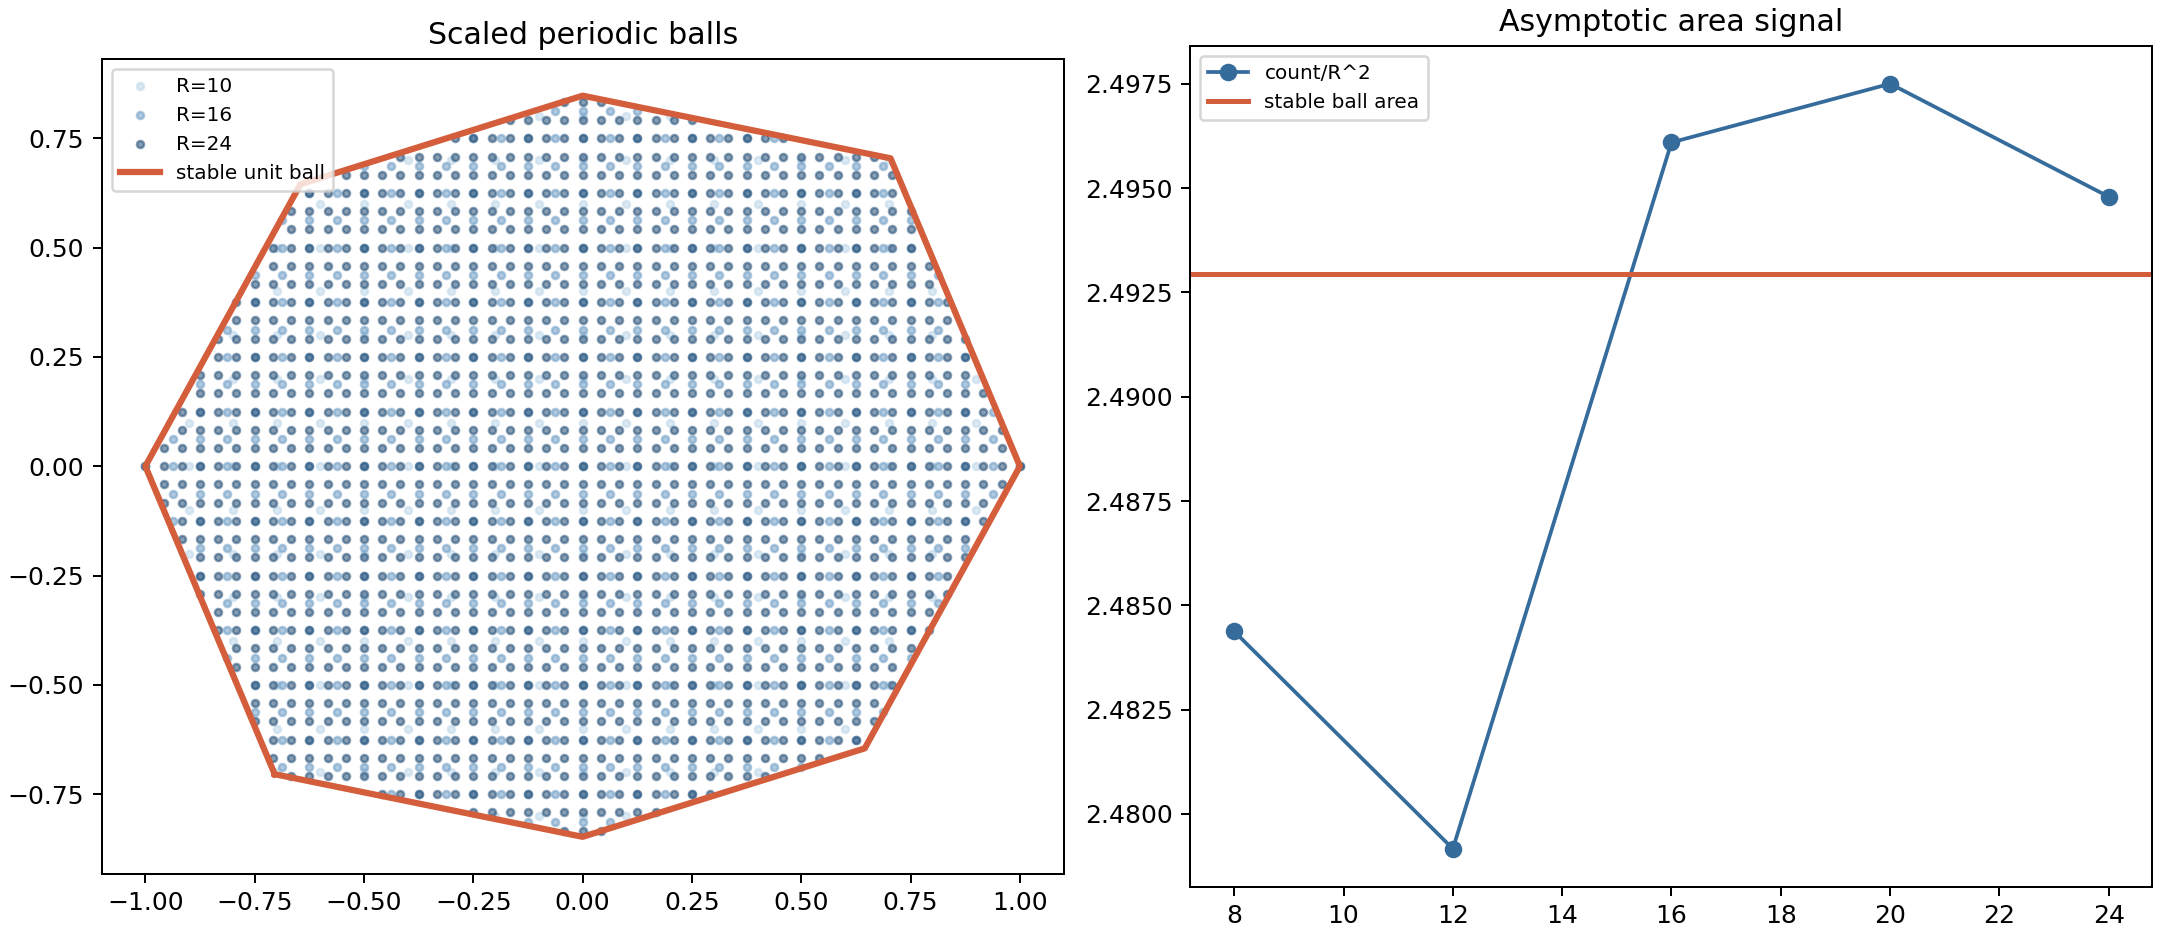

[`artifacts/chapter-08/tables/periodic-growth.csv`](artifacts/chapter-08/tables/periodic-growth.csv)

{'generators_with_costs': [{'step': (1, 0), 'cost': 1.0},
  {'step': (0, 1), 'cost': 1.18},
  {'step': (1, 1), 'cost': 1.42},
  {'step': (1, -1), 'cost': 1.55}],
 'stable_unit_ball_vertices': [[-0.7042253521126761, -0.7042253521126761],
  [0.0, -0.8474576271186441],
  [0.6451612903225806, -0.6451612903225806],
  [1.0, 0.0],
  [0.7042253521126761, 0.7042253521126761],
  [0.0, 0.8474576271186441],
  [-0.6451612903225806, 0.6451612903225806],
  [-1.0, 0.0]],
 'stable_unit_ball_area': 2.4929346444990337,
 'growth_rows': [{'radius': 8,
   'lattice_ball_count': 159,
   'count_over_radius_squared': 2.484375},
  {'radius': 12,
   'lattice_ball_count': 357,
   'count_over_radius_squared': 2.4791666666666665},
  {'radius': 16,
   'lattice_ball_count': 639,
   'count_over_radius_squared': 2.49609375},
  {'radius': 20,
   'lattice_ball_count': 999,
   'count_over_radius_squared': 2.4975},
  {'radius': 24,
   'lattice_ball_count': 1437,
   'count_over_radius_squared': 2.4947916666666665}],
 'max_ho

In [6]:
base = [((1,0),1.00), ((0,1),1.18), ((1,1),1.42), ((1,-1),1.55)]
gens = []
for step, cost in base:
    x, y = step; gens += [((x, y), cost), ((-x, -y), cost)]
A = np.array([[s[0], s[1]] for s, _ in gens], float).T
c = np.array([cost for _, cost in gens], float)
def stable_norm(v):
    if v == (0, 0): return 0.0
    out = linprog(c, A_eq=A, b_eq=np.array(v, float), bounds=[(0, None)] * len(gens), method="highs")
    if not out.success: raise RuntimeError(out.message)
    return float(out.fun)
def weighted_graph(limit):
    G = nx.Graph()
    for x in range(-limit, limit+1):
        for y in range(-limit, limit+1):
            G.add_node((x,y))
    for x, y in list(G.nodes):
        for (dx,dy), cost in gens:
            z = (x+dx, y+dy)
            if z in G: G.add_edge((x,y), z, weight=cost)
    return G
WG = weighted_graph(34)
dist = nx.single_source_dijkstra_path_length(WG, (0,0), weight="weight")
radii = [8, 12, 16, 20, 24]
growth = pd.DataFrame([{"radius": R, "lattice_ball_count": sum(v <= R + 1e-9 for v in dist.values())} for R in radii])
growth["count_over_radius_squared"] = growth["lattice_ball_count"] / growth["radius"]**2
growth_csv = TABLE / "periodic-growth.csv"; growth.to_csv(growth_csv, index=False)
verts = np.array([(dx/cost, dy/cost) for (dx,dy), cost in gens], float)
poly = verts[ConvexHull(verts).vertices]; poly = poly[np.argsort(np.arctan2(poly[:,1], poly[:,0]))]
area = 0.5 * abs(np.dot(poly[:,0], np.roll(poly[:,1], -1)) - np.dot(poly[:,1], np.roll(poly[:,0], -1)))
fig, ax = plt.subplots(1, 2, figsize=(12, 5.2), constrained_layout=True)
for R, color in zip([10,16,24], ["#bfd7ea", "#6f9ec6", "#244f77"]):
    pts = np.array([np.array(n, float)/R for n, d in dist.items() if d <= R + 1e-9])
    ax[0].scatter(pts[:,0], pts[:,1], s=8, color=color, alpha=.55, label=f"R={R}")
closed = np.vstack([poly, poly[0]])
ax[0].plot(closed[:,0], closed[:,1], color="#d45d3c", lw=2.5, label="stable unit ball")
ax[0].set_aspect("equal"); ax[0].set_title("Scaled periodic balls"); ax[0].legend(fontsize=8)
ax[1].plot(growth["radius"], growth["count_over_radius_squared"], "o-", color="#356c9b", label="count/R^2")
ax[1].axhline(area, color="#d45d3c", lw=2, label="stable ball area"); ax[1].set_title("Asymptotic area signal"); ax[1].legend(fontsize=8)
periodic_fig = FIG / "periodic-stable-norm-ball.png"
fig.savefig(periodic_fig, dpi=180); plt.close(fig)
tests = [(3,1), (4,0), (2,-3), (5,5), (-4,2)]
hom = [abs(stable_norm((2*x,2*y)) - 2*stable_norm((x,y))) for x,y in tests]
diffs = [dist[v] - stable_norm(v) for v in [(x,y) for x in range(-9,10) for y in range(-9,10) if (x,y)!=(0,0)]]
pcheck = {"generators_with_costs": [{"step": s, "cost": cost} for s, cost in base], "stable_unit_ball_vertices": poly.tolist(), "stable_unit_ball_area": float(area), "growth_rows": growth.to_dict("records"), "max_homogeneity_residual_for_test_vectors": float(max(hom)), "integer_metric_minus_stable_norm": {"sample_count": len(diffs), "max_difference": float(max(diffs)), "min_difference": float(min(diffs))}}
write_json(CHECK / "periodic-stable-norm-checks.json", pcheck)
display_artifact(periodic_fig); display_artifact(growth_csv); pcheck


## Applied Lab

Use the artifacts as a diagnostic checklist. In the pointed-cycle model, change the radius before changing the cycle size; convergence is radius-by-radius. In the cone lab, watch the mesh bound rather than the raw point count. In the quasi-isometry plot, compare coarse growth rather than local topology. In the hyperbolicity JSON, read the witness quadruple as a concrete failure of tree behavior. In the periodic metric figure, compare the scaled discrete balls with the stable norm polygon.


In [7]:
required = [
    FIG / "pointed-cycle-balls-limit.png",
    FIG / "cone-rescaling-snapshots.png",
    HTML_DIR / "cone-rescaling-lab.html",
    FIG / "quasi-isometry-net-growth.png",
    FIG / "hyperbolicity-diagnostics.png",
    FIG / "periodic-stable-norm-ball.png",
    CHECK / "visual-storyboard.json",
    CHECK / "source-coverage.json",
    CHECK / "noncompact-pointed-limit.json",
    CHECK / "cone-rescaling-checks.json",
    CHECK / "quasi-isometry-checks.json",
    CHECK / "hyperbolicity-residuals.json",
    CHECK / "periodic-stable-norm-checks.json",
    TABLE / "periodic-growth.csv",
]
records = [{"path": rel(p), "exists": p.exists(), "bytes": p.stat().st_size if p.exists() else 0} for p in required]
loaded = {p.name: json.loads(p.read_text(encoding="utf-8")) for p in CHECK.glob("*.json") if p.name != "final-sanity.json"}
final_sanity = {
    "source_span": {"printed": "271-306", "pdf": "286-321"},
    "artifact_records": records,
    "assertions": {
        "all_required_artifacts_exist_and_are_nonempty": all(r["exists"] and r["bytes"] > 100 for r in records),
        "noncompact_local_stability": loaded["noncompact-pointed-limit.json"]["eventual_local_stability_detected"],
        "cone_covering_radius_decreases": loaded["cone-rescaling-checks.json"]["covering_radius_strictly_decreases"],
        "quasi_isometry_samples_pass": len(loaded["quasi-isometry-checks.json"]["violations"]) == 0,
        "tree_four_point_delta_zero": loaded["hyperbolicity-residuals.json"]["tree_zero_four_point_delta"],
        "grid_residual_larger_than_tree": loaded["hyperbolicity-residuals.json"]["grid_has_larger_residual_than_tree"],
        "stable_norm_homogeneity_sampled": loaded["periodic-stable-norm-checks.json"]["max_homogeneity_residual_for_test_vectors"] < 1e-8,
    },
    "standalone_contract": True,
    "pdf_used_for": "section structure, terminology, and page-span orientation only",
}
write_json(CHECK / "final-sanity.json", final_sanity)
assert final_sanity["assertions"]["all_required_artifacts_exist_and_are_nonempty"]
assert all(final_sanity["assertions"].values())
final_sanity


{'source_span': {'printed': '271-306', 'pdf': '286-321'},
 'artifact_records': [{'path': 'artifacts/chapter-08/figures/pointed-cycle-balls-limit.png',
   'exists': True,
   'bytes': 96836},
  {'path': 'artifacts/chapter-08/figures/cone-rescaling-snapshots.png',
   'exists': True,
   'bytes': 110060},
  {'path': 'artifacts/chapter-08/html/cone-rescaling-lab.html',
   'exists': True,
   'bytes': 149354},
  {'path': 'artifacts/chapter-08/figures/quasi-isometry-net-growth.png',
   'exists': True,
   'bytes': 104396},
  {'path': 'artifacts/chapter-08/figures/hyperbolicity-diagnostics.png',
   'exists': True,
   'bytes': 84811},
  {'path': 'artifacts/chapter-08/figures/periodic-stable-norm-ball.png',
   'exists': True,
   'bytes': 206264},
  {'path': 'artifacts/chapter-08/checks/visual-storyboard.json',
   'exists': True,
   'bytes': 517},
  {'path': 'artifacts/chapter-08/checks/source-coverage.json',
   'exists': True,
   'bytes': 1838},
  {'path': 'artifacts/chapter-08/checks/noncompact-po

## Takeaways

Large-scale geometry replaces exact local shape with controlled error. Pointed convergence asks every fixed ball to settle down. Tangent and asymptotic cones are rescaling limits. Quasi-isometry makes nets and cocompact orbits legitimate stand-ins for full spaces. Gromov hyperbolicity is the distance-only signature of tree-like negative-curvature behavior. Periodic metrics have stable norm balls as their asymptotic geometry.
